### 🎯 Project Objective  

- The objective of this project is to build a Linear Regression model trained using **Gradient Descent** to predict the **number of hired bikes** based on feature temperature and then based on multiple features  
- The project demonstrates how gradient descent iteratively minimizes the loss function, visualizes the fitted regression line against real data, and analyses how model loss decreases across iterations.

### Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("bike_sharing_demand.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


### Demand distribution - Histogram of demand

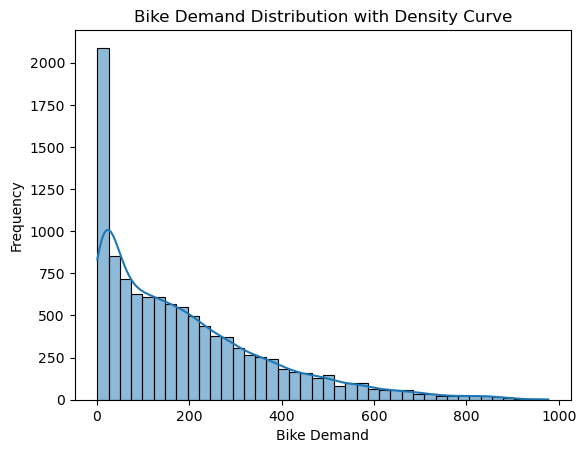

In [2]:
import seaborn as sns

plt.figure()
sns.histplot(df['count'], bins=40, kde=True)
plt.title("Bike Demand Distribution with Density Curve")
plt.xlabel("Bike Demand")
plt.ylabel("Frequency")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Temp vs demand - Scatter plot

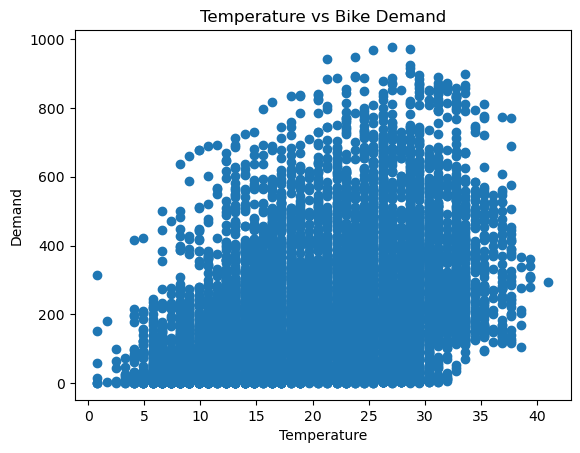

In [3]:
plt.figure()
plt.scatter(df['temp'], df['count'])
plt.title("Temperature vs Bike Demand")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\temp_vs_demand.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Hour vs demand - line chart

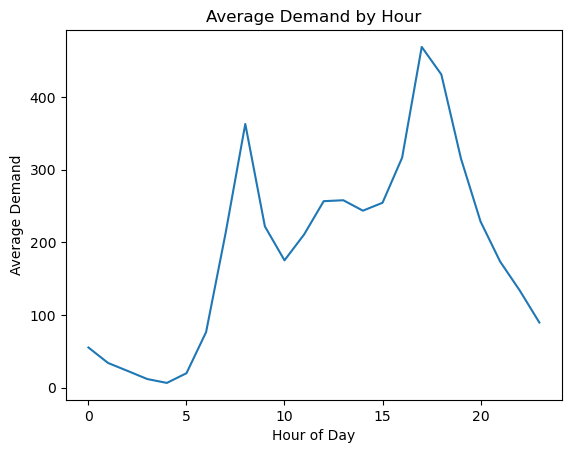

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

hourly = df.groupby('hour')['count'].mean()

plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Average Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\hours_vs_demand.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Prepare data

In [5]:
X = df['temp'].values.reshape(-1,1)
y = df['count'].values.reshape(-1,1)
m = len(y)

### Feature scaling

In [6]:
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

### Add bias term

In [7]:
Xb = np.c_[np.ones((X_scaled.shape[0],1)), X_scaled]

### Initialize parameters and hyperparameters

In [8]:
theta = np.zeros((2,1))
alpha = 0.01
iterations = 300
losses = []

### Implement Gradient Descent loop

In [9]:
for i in range(iterations):
    y_pred = Xb.dot(theta)
    error = y_pred - y
    
    cost = (1/(2*m)) * np.sum(error**2)
    losses.append(cost)
    
    gradients = (1/m) * Xb.T.dot(error)
    theta = theta - alpha * gradients

### Scatter plot + Regression line

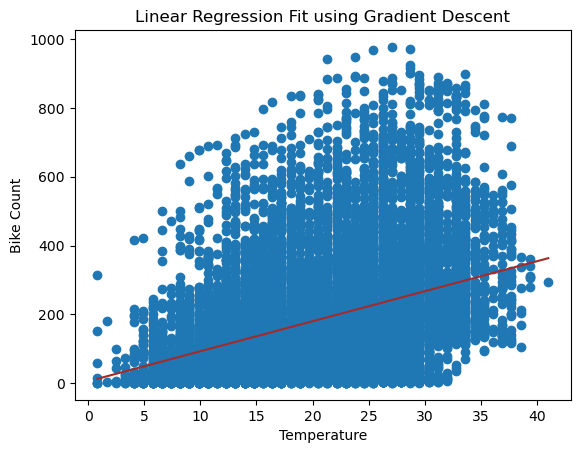

In [10]:
# Create prediction line
x_line = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1,1)
x_line_b = np.c_[np.ones((100,1)), x_line]
y_line = x_line_b.dot(theta)

# Convert back to original scale for readability
x_line_unscaled = x_line * X_std + X_mean

plt.figure()
plt.scatter(X, y)
plt.plot(x_line_unscaled, y_line, color='brown')
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.title("Linear Regression Fit using Gradient Descent")
plt.show()

### Actual vs predicted

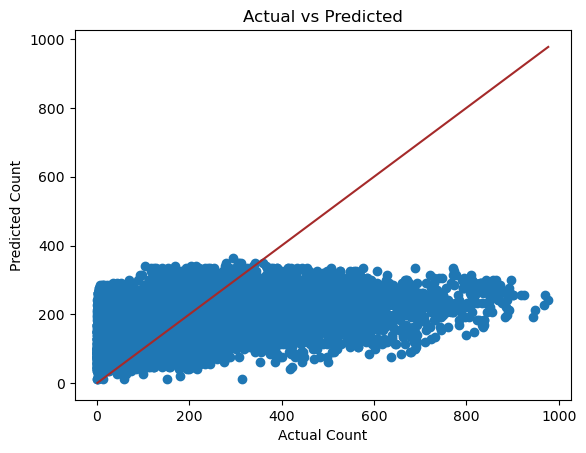

In [11]:
y_pred = Xb.dot(theta)

plt.figure()
plt.scatter(y, y_pred)
line = np.linspace(y.min(), y.max(), 100)
plt.plot(line, line, color="brown")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\actual_vs_predicted_only_with_temp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key insight

- As temperature increases, bike usage also increases
- The line represents the average expected bike demand at each temperature
- The chart tells how strongly temperature influences bike demand and what demand to expect at different temperatures

### Loss Curve (Cost vs Iterations)

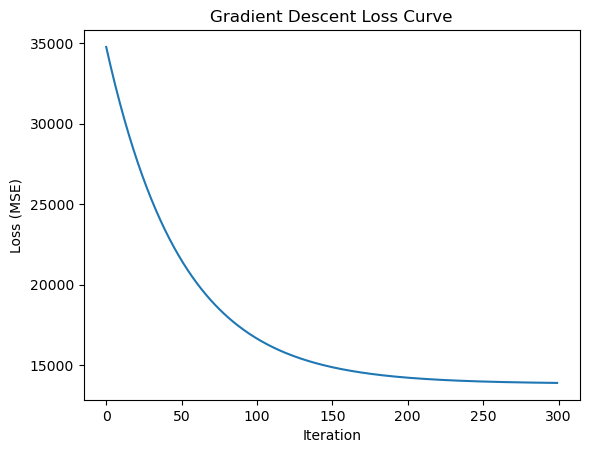

In [12]:
plt.figure()
plt.plot(range(iterations), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Loss Curve")
plt.show()

### Key insights

- At the beginning, the loss is high — meaning the model’s predictions were inaccurate.
- As training progresses, the loss steadily decreases, showing that the model is learning and improving its accuracy.
- The curve flattening toward the end means the model has stabilized and further training brings little additional benefit.

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_final = Xb.dot(theta)

mse = mean_squared_error(y, y_pred_final)
r2 = r2_score(y, y_pred_final)

mse, r2

(27805.766957811757, 0.1525293001985486)

### Key insights

- The model’s prediction errors are still quite high, so forecasts shouldn’t be fully relied on for precise planning
- Temperature does have some impact, but it’s not the main driver of bike demand. You need more variables to build a reliable forecasting model

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [15]:
X_mean = X_train.mean()
X_std = X_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [16]:
Xb_train = np.c_[np.ones((X_train_scaled.shape[0],1)), X_train_scaled]
Xb_test  = np.c_[np.ones((X_test_scaled.shape[0],1)), X_test_scaled]

In [17]:
theta = np.zeros((2,1))
alpha = 0.01
iterations = 300
losses = []
m = len(y_train)

In [18]:
for i in range(iterations):
    y_pred = Xb_train.dot(theta)
    error = y_pred - y_train
    gradients = (1/m) * Xb_train.T.dot(error)
    theta = theta - alpha * gradients

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

y_test_pred = Xb_test.dot(theta)

mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

mse, r2

(27578.811688169924, 0.16445404684221243)

## Build the model using multiple features and gradient descent

### Select multiple features converting datetime to hour and target

In [20]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

In [21]:
X = df[['temp','humidity','windspeed','season','workingday','weather','hour']]
y = df[['count']]

### Train-Test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

### Feature scaling

In [23]:
X_mean = X_train.mean()
X_std = X_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

### Add bias term

In [24]:
Xb_train = np.c_[np.ones((X_train_scaled.shape[0],1)), X_train_scaled]
Xb_test  = np.c_[np.ones((X_test_scaled.shape[0],1)), X_test_scaled]

### Convert target to NumPy

In [25]:
y_train_np = y_train.values
y_test_np = y_test.values

### Initialize Parameters & Hyperparameters

In [26]:
theta = np.zeros((Xb_train.shape[1],1))
alpha = 0.05
iterations = 1200
losses = []
m = len(y_train_np)

### Gradient Descent Loop

In [27]:
for i in range(iterations):
    
    y_pred = Xb_train.dot(theta)
    
    error = y_pred - y_train_np
    
    gradients = (1/m) * Xb_train.T.dot(error)
    
    theta = theta - alpha * gradients
    
    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)

### Plot training loss curve

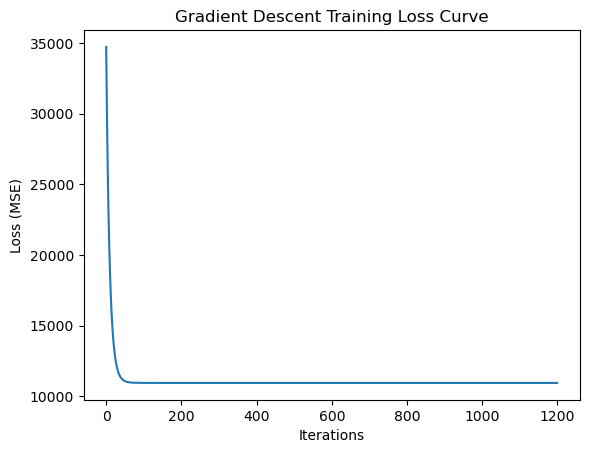

In [28]:
plt.figure()
plt.plot(range(iterations), losses)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Training Loss Curve")
plt.show()

### Evaluation on test data

In [29]:
y_test_pred = Xb_test.dot(theta)

mse = mean_squared_error(y_test_np, y_test_pred)
r2 = r2_score(y_test_np, y_test_pred)

mse, r2

(21730.966197139292, 0.3416242487337826)

### Plot predicted vs actual

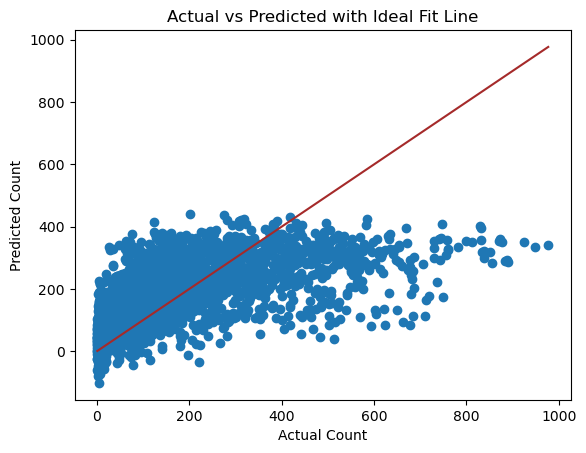

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test_np, y_test_pred)

# ideal line
line = np.linspace(y_test_np.min(), y_test_np.max(), 100)
plt.plot(line, line, color="brown")

plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted with Ideal Fit Line")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\actual_vs_predicted_with_multiple_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Residual plot

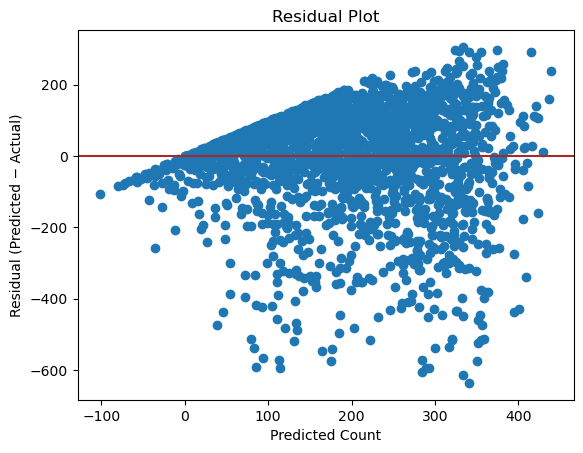

In [31]:
residuals = y_test_pred - y_test_np

plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(0,color="brown")
plt.xlabel("Predicted Count")
plt.ylabel("Residual (Predicted − Actual)")
plt.title("Residual Plot")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\03_linear_regression_bike_sharing_demand\images\residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Error distribution

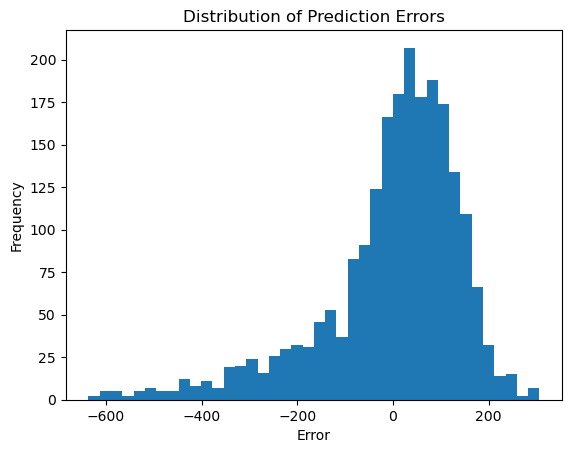

In [32]:
plt.figure()
plt.hist(residuals, bins=40)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

## Random Forest Regression

### Import required libraries

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### One-hot encoding of categorical features

In [34]:
X = pd.get_dummies(X, columns=['season', 'weather', 'hour'], drop_first=True)

### Train_Test split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Create Random Forest model

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=200,     # number of trees
    max_depth=None,       # trees grow fully
    random_state=42,
    n_jobs=-1             # use all CPU cores
)

### Train the model

In [37]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

### Make predictions

In [38]:
y_pred_rf = rf_model.predict(X_test)

### Evaluate performance

In [39]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_rf, r2_rf

(6154.656864333922, 0.8135344374436949)

## Gradient Boosting Regression

### Import required libraries

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

### Create model

In [41]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,   # number of boosting stages
    learning_rate=0.05, # step size
    max_depth=3,        # tree depth
    random_state=42
)

### Train the model

In [42]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

### Make predictions

In [43]:
y_pred_gb = gb_model.predict(X_test)

### Evaluate the model

In [44]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

mse_gb, r2_gb

(8699.675398956331, 0.7364288695403657)

### Compare all the models

In [45]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [r2, r2_rf, r2_gb]
})

results

,Model,R2 Score
0,Linear Regression,0.341624
1,Random Forest,0.813534
2,Gradient Boosting,0.736429


### Save the Random Forest model

In [46]:
import joblib
joblib.dump(rf_model, "bike_demand_rf_model.pkl")

['bike_demand_rf_model.pkl']

### Save feature columns

In [47]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']

### Actual vs Predicted (all models comparison)

Lengths: y_test=2178, linear=8708, rf=2178, gb=2178


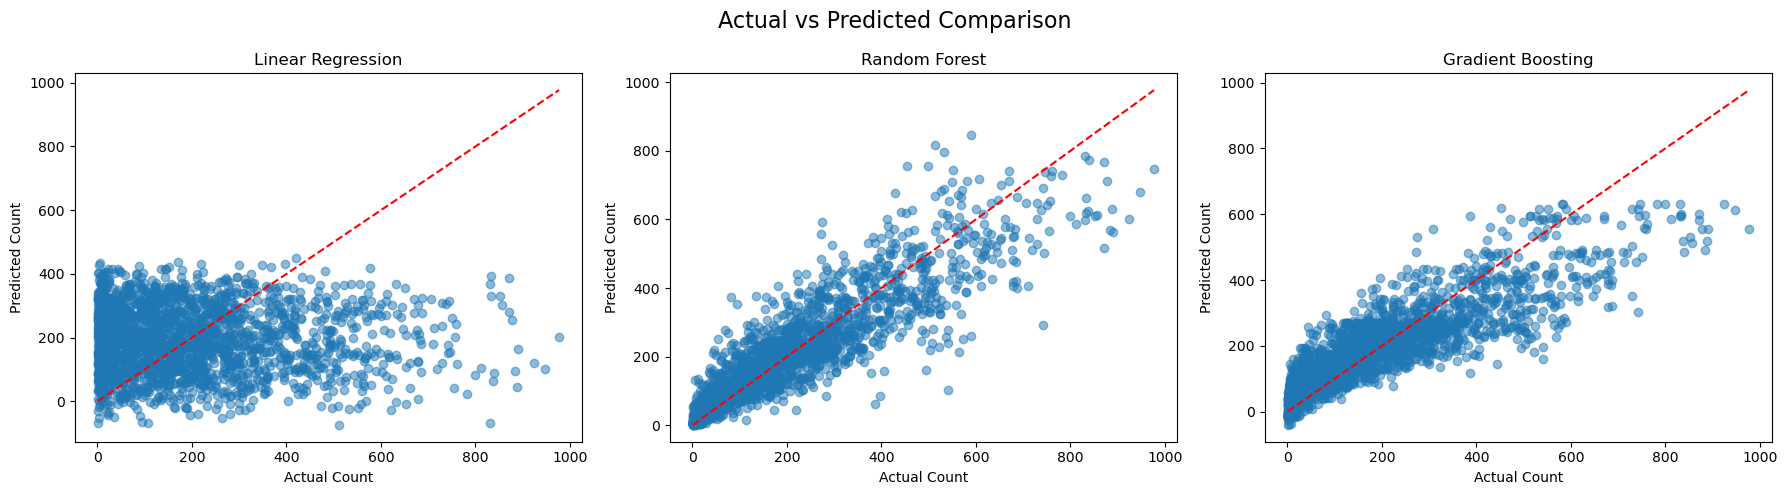

In [62]:
# Convert to 1D arrays (important!)
y_test_arr = np.ravel(y_test)
y_pred_linear_arr = np.ravel(y_pred)
y_pred_rf_arr = np.ravel(y_pred_rf)
y_pred_gb_arr = np.ravel(y_pred_gb)

# Check that all arrays have the same length
# If they don't, you might need to align your data or investigate why predictions have different lengths
print(f"Lengths: y_test={len(y_test_arr)}, linear={len(y_pred_linear_arr)}, rf={len(y_pred_rf_arr)}, gb={len(y_pred_gb_arr)}")

# Make sure to use only the common indices if lengths differ
min_length = min(len(y_test_arr), len(y_pred_linear_arr), len(y_pred_rf_arr), len(y_pred_gb_arr))
y_test_arr = y_test_arr[:min_length]
y_pred_linear_arr = y_pred_linear_arr[:min_length]
y_pred_rf_arr = y_pred_rf_arr[:min_length]
y_pred_gb_arr = y_pred_gb_arr[:min_length]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("Linear Regression", y_pred_linear_arr),
    ("Random Forest", y_pred_rf_arr),
    ("Gradient Boosting", y_pred_gb_arr)
]

for ax, (name, preds) in zip(axes, models):
    ax.scatter(y_test_arr, preds, alpha=0.5)
    ax.plot([y_test_arr.min(), y_test_arr.max()],
            [y_test_arr.min(), y_test_arr.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel("Actual Count")
    ax.set_ylabel("Predicted Count")

plt.suptitle("Actual vs Predicted Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\03_linear_regression_bike_sharing_demand\images\actual_vs_predicted_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [59]:
### Models behaviour comparison

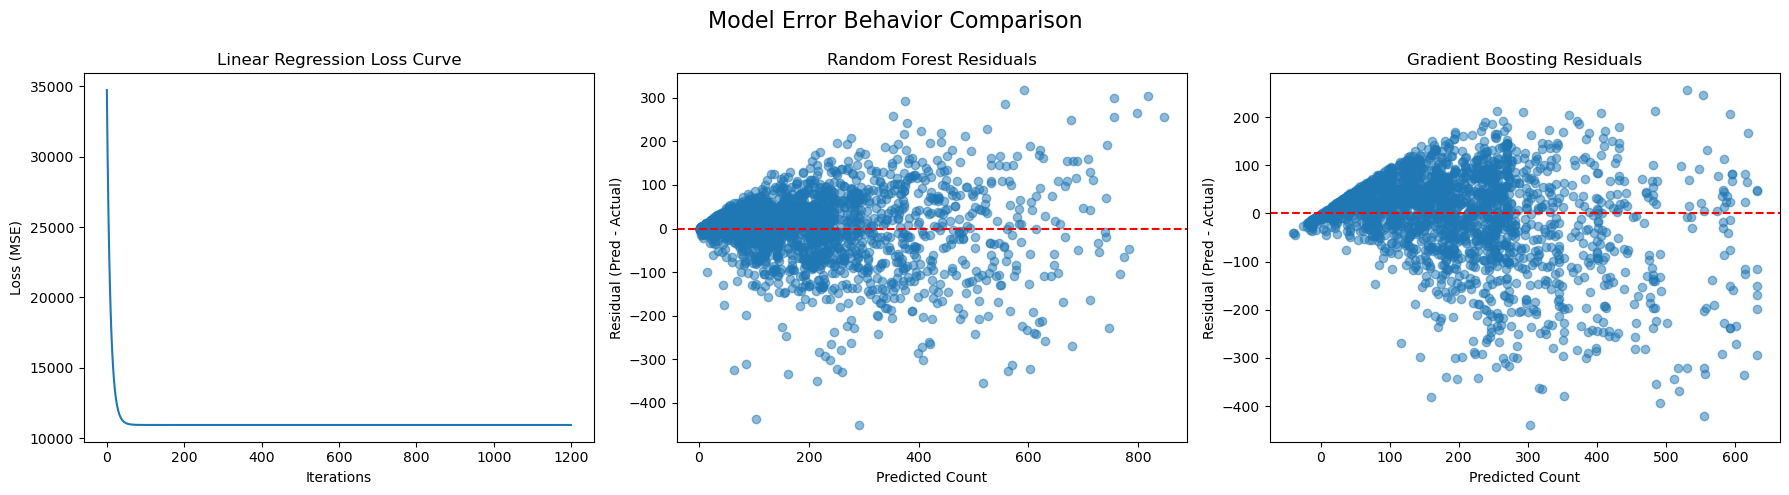

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 1. Linear Regression Loss Curve
axes[0].plot(losses)
axes[0].set_title("Linear Regression Loss Curve")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss (MSE)")

# 🔹 2. Random Forest Residuals
rf_residuals = y_pred_rf_arr - y_test_arr
axes[1].scatter(y_pred_rf_arr, rf_residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Random Forest Residuals")
axes[1].set_xlabel("Predicted Count")
axes[1].set_ylabel("Residual (Pred - Actual)")

# 🔹 3. Gradient Boosting Residuals
gb_residuals = y_pred_gb_arr - y_test_arr
axes[2].scatter(y_pred_gb_arr, gb_residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_title("Gradient Boosting Residuals")
axes[2].set_xlabel("Predicted Count")
axes[2].set_ylabel("Residual (Pred - Actual)")

plt.suptitle("Model Error Behavior Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\03_linear_regression_bike_sharing_demand\images\all_models_behaviour_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 🧠 Key Insights (Technical + Business)

### 📌 Model Performance Insights

|Model|R² Score|Interpretation|
|---|---|---|
|Linear Regression|0.34|Too simple, underfits|
|Random Forest|0.81|Captures complex patterns best|
|Gradient Boosting|0.73|Strong but slightly less than RF|
                                  
### 🔍 What We Learned

- Bike demand is not linear
- Multiple interacting features matter
- Tree models capture real-world complexity

### 🚲 Business Insights from the Data

### **🌡 Temperature**

Higher temperatures significantly increase bike demand
→ Summer marketing campaigns can increase revenue

### **🕒 Hour of Day**

Peak usage during:  
- Morning commute (7–9 AM)  
- Evening commute (5–7 PM)  
→ Deploy more bikes during rush hours

### **🌧 Weather**

Bad weather reduces rentals → Lower inventory needed on rainy days

### **🏢 Working Days vs Weekends**

Usage patterns differ:
- Working days → commute driven
- Weekends → leisure driven

### 💡 Operational Value
|Insight|Business Action|
|---|---|
|Demand peaks at certain hours|Smart bike redistribution|
|Weather impacts demand|Predictive maintenance & staffing|
|Seasonality matters|Seasonal pricing strategies|
|Model can predict demand|Inventory planning & cost reduction|
                                  
### 🏁 Final Conclusion

This project demonstrates:

✔ End-to-end ML workflow  
✔ Model comparison & selection  
✔ Real-world deployment potential  
✔ Business decision support  

Random Forest chosen for deployment due to highest predictive accuracy.